In [27]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "x": [1, 2, 3, 4, 5],
    "y": [2, 5, 10, 17, 26]
})

df

,x,y
0,1,2
1,2,5
2,3,10
3,4,17
4,5,26


In [28]:
from sklearn.preprocessing import PolynomialFeatures

poly =PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(df[['x']])

print(X_poly)

[[ 1.  1.]
 [ 2.  4.]
 [ 3.  9.]
 [ 4. 16.]
 [ 5. 25.]]


In [29]:
poly3 = PolynomialFeatures(
    degree=3,
    include_bias=False
)

X_poly3 = poly3.fit_transform(
    df[["x"]]
)

print(X_poly3)

[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]]


In [30]:
import pandas as pd

df = pd.DataFrame({
    "area": [100, 200, 300],
    "bedrooms": [1, 2, 3]
})

X = df[["area", "bedrooms"]]

print(X)

   area  bedrooms
0   100         1
1   200         2
2   300         3


In [31]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

print(X_poly)

[[1.e+02 1.e+00 1.e+04 1.e+02 1.e+00]
 [2.e+02 2.e+00 4.e+04 4.e+02 4.e+00]
 [3.e+02 3.e+00 9.e+04 9.e+02 9.e+00]]


In [32]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "x":[1,2,3,4,5],
    "y":[2,5,10,17,26]
})
X= df[["x"]]
y= df[["y"]]

In [33]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X,y)

y_pred_linear = linear_model.predict(X)

print("Linear Predictions:")
print(y_pred_linear)

Linear Predictions:
[[2.66453526e-15]
 [6.00000000e+00]
 [1.20000000e+01]
 [1.80000000e+01]
 [2.40000000e+01]]


In [34]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_model=PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly=polynomial_model.fit_transform(X)

print(X_poly)

[[ 1.  1.]
 [ 2.  4.]
 [ 3.  9.]
 [ 4. 16.]
 [ 5. 25.]]


In [35]:
poly_model =LinearRegression()

poly_model.fit(X_poly,y)

y_pred_poly = poly_model.predict(X_poly)

print("Polynomial Predictions:")
print(y_pred_poly)



Polynomial Predictions:
[[ 2.]
 [ 5.]
 [10.]
 [17.]
 [26.]]


In [36]:
from sklearn.metrics import r2_score,mean_squared_error

linear_r2 = r2_score(y,y_pred_linear)
poly_r2=   r2_score(y,y_pred_poly)

print("Linear Regression R2:",linear_r2)
print("Polynomial Regression",poly_r2)

Linear Regression R2: 0.9625668449197862
Polynomial Regression 1.0


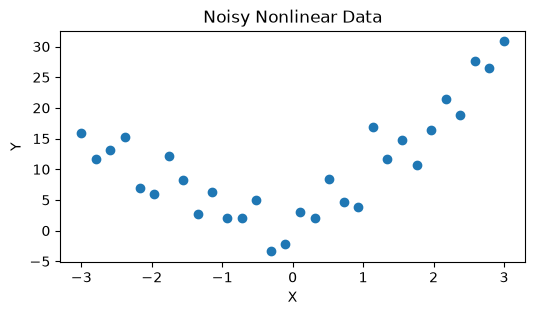

In [37]:
#Creating Non linear Dataset 
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(-3, 3, 30).reshape(-1, 1)

y = 2 * X.ravel()**2 + 3 * X.ravel() + 5 + np.random.normal(
    0, 4, 30
)

plt.figure(figsize=(6, 3))

plt.scatter(X, y)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Noisy Nonlinear Data")

plt.show()

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24, 1)
X_test: (6, 1)
y_train: (24,)
y_test: (6,)


In [40]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

degrees= [1,2,3,5,10]

for degree in degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)


    model = LinearRegression()
    model.fit(X_train_poly,y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_r2 = r2_score(y_train,y_train_pred)
    test_r2 = r2_score(y_test,y_test_pred)

    print(f"Degree :{degree}")
    print(f"Train r2: {train_r2:.4f}")
    print(f"Test r2: {test_r2:.4f}")
    print("-"*30)





Degree :1
Train r2: 0.1922
Test r2: 0.3844
------------------------------
Degree :2
Train r2: 0.8505
Test r2: 0.8957
------------------------------
Degree :3
Train r2: 0.8505
Test r2: 0.8958
------------------------------
Degree :5
Train r2: 0.8773
Test r2: 0.8471
------------------------------
Degree :10
Train r2: 0.9099
Test r2: 0.7015
------------------------------


In [46]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create fresh noisy nonlinear data
np.random.seed(42)

X_noisy = np.linspace(-3, 3, 30).reshape(-1, 1)

y_noisy = (
    2 * X_noisy.ravel()**2
    + 3 * X_noisy.ravel()
    + 5
    + np.random.normal(0, 4, 30)
)

# Train-test split
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy,
    y_noisy,
    test_size=0.2,
    random_state=42
)

print("X_noisy shape:", X_noisy.shape)
print("X_train_n shape:", X_train_n.shape)
print("X_test_n shape:", X_test_n.shape)

X_noisy shape: (30, 1)
X_train_n shape: (24, 1)
X_test_n shape: (6, 1)


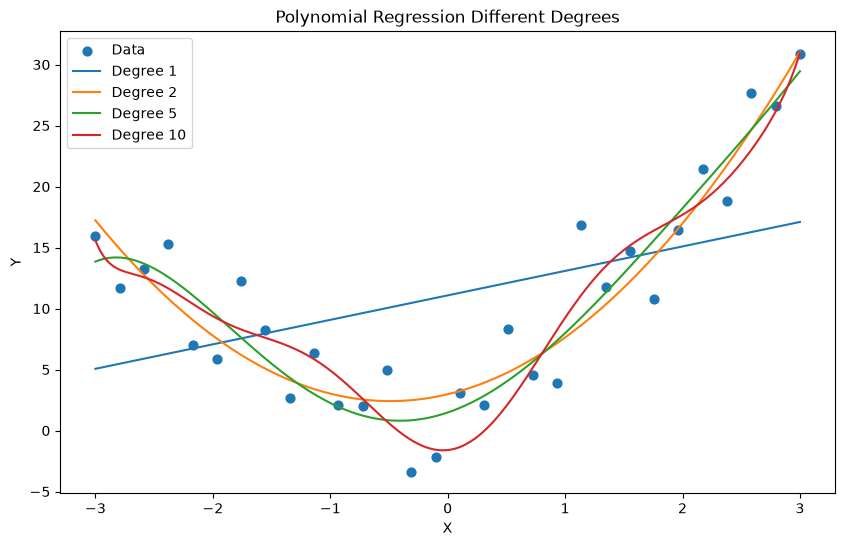

In [47]:
degrees = [1, 2, 5, 10]

plt.figure(figsize=(10, 6))

# Original data
plt.scatter(
    X_noisy.ravel(),
    y_noisy,
    s=40,
    label="Data"
)

# Smooth X values
X_curve = np.linspace(
    X_noisy.min(),
    X_noisy.max(),
    300
).reshape(-1, 1)

for degree in degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    # Transform training data
    X_train_poly = poly.fit_transform(X_train_n)

    # Transform smooth curve
    X_curve_poly = poly.transform(X_curve)

    # Train model
    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train_n
    )

    # Predict
    y_curve = model.predict(X_curve_poly)

    # Plot
    plt.plot(
        X_curve.ravel(),
        y_curve,
        label=f"Degree {degree}"
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression Different Degrees")

plt.legend()
plt.show()

In [48]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=10,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_n)
X_test_poly = poly.transform(X_test_n)

print("Training shape:", X_train_poly.shape)
print("Testing shape:", X_test_poly.shape)

Training shape: (24, 10)
Testing shape: (6, 10)


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

linear_model = LinearRegression()

linear_model.fit(
    X_train_poly,
    y_train_n
)

train_pred = linear_model.predict(X_train_poly)
test_pred = linear_model.predict(X_test_poly)

print("Linear Regression")
print("Train R²:", r2_score(y_train_n, train_pred))
print("Test R²:", r2_score(y_test_n, test_pred))

Linear Regression
Train R²: 0.9099347538808166
Test R²: 0.7015394361685505


In [51]:
from sklearn.linear_model import Ridge

ridge_model =Ridge(alpha= 1)

ridge_model.fit(X_train_poly,y_train_n)

ridge_train_pred = ridge_model.predict(X_train_poly)
ridge_test_pred = ridge_model.predict(X_test_poly)


print("Regression")
print("Train",r2_score(y_train_n,ridge_train_pred))
print("Test",r2_score(y_test_n,ridge_test_pred))



Regression
Train 0.8964796231244346
Test 0.7229770534793558


In [52]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(
        X_train_poly,
        y_train_n
    )

    train_pred = ridge.predict(X_train_poly)
    test_pred = ridge.predict(X_test_poly)

    train_r2 = r2_score(y_train_n, train_pred)
    test_r2 = r2_score(y_test_n, test_pred)

    print(f"Alpha = {alpha}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²:  {test_r2:.4f}")
    print("-" * 30)

Alpha = 0.01
Train R²: 0.9099
Test R²:  0.7030
------------------------------
Alpha = 0.1
Train R²: 0.9075
Test R²:  0.7081
------------------------------
Alpha = 1
Train R²: 0.8965
Test R²:  0.7230
------------------------------
Alpha = 10
Train R²: 0.8637
Test R²:  0.8088
------------------------------
Alpha = 100
Train R²: 0.8019
Test R²:  0.8841
------------------------------


In [57]:
from sklearn.preprocessing import StandardScaler

scaler_poly = StandardScaler()

X_train_poly_scaled = scaler_poly.fit_transform(
    X_train_poly
)

X_test_poly_scaled = scaler_poly.transform(
    X_test_poly
)

In [59]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

lasso = Lasso(
    alpha=0.1,
    max_iter=10000
)

lasso.fit(
    X_train_poly_scaled,
    y_train_n
)

lasso_train_pred = lasso.predict(
    X_train_poly_scaled
)

lasso_test_pred = lasso.predict(
    X_test_poly_scaled
)

print("Lasso Regression")

print(
    "Train R²:",
    r2_score(y_train_n, lasso_train_pred)
)

print(
    "Test R²:",
    r2_score(y_test_n, lasso_test_pred)
)

Lasso Regression
Train R²: 0.8641143167191248
Test R²: 0.8832123663448963


In [60]:
for power, coefficient in enumerate(
    lasso.coef_,
    start=1
):
    print(
        f"X^{power}: {coefficient:.6f}"
    )

X^1: 4.020350
X^2: 8.109279
X^3: 0.000000
X^4: -0.000000
X^5: 0.000000
X^6: -1.446461
X^7: 0.000000
X^8: -0.000000
X^9: 0.254645
X^10: -0.000000


In [63]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_poly_scaled,y_train_n)

elastic_train_pred = elastic_model.predict(X_train_poly_scaled)
elastic_test_pred = elastic_model.predict(X_test_poly_scaled)


In [64]:
from sklearn.metrics import r2_score

print("Elastic Net")
print(
    "Train R²:",
    r2_score(y_train_n, elastic_train_pred)
)

print(
    "Test R²:",
    r2_score(y_test_n, elastic_test_pred)
)

Elastic Net
Train R²: 0.8506190410572483
Test R²: 0.8961479286304759


In [65]:
for power, coefficient in enumerate(
    elastic_model.coef_,
    start=1
):
    print(
        f"X^{power}: {coefficient:.6f}"
    )

X^1: 3.447298
X^2: 6.742257
X^3: 0.333842
X^4: 0.000000
X^5: 0.000000
X^6: -0.000000
X^7: 0.112826
X^8: -0.204405
X^9: 0.264929
X^10: -0.081014


In [66]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

ratios = [0, 0.25, 0.5, 0.75, 1]

for ratio in ratios:

    model = ElasticNet(
        alpha=0.1,
        l1_ratio=ratio,
        max_iter=10000
    )

    model.fit(
        X_train_poly_scaled,
        y_train_n
    )

    train_pred = model.predict(
        X_train_poly_scaled
    )

    test_pred = model.predict(
        X_test_poly_scaled
    )

    train_r2 = r2_score(
        y_train_n,
        train_pred
    )

    test_r2 = r2_score(
        y_test_n,
        test_pred
    )

    print(f"l1_ratio = {ratio}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²:  {test_r2:.4f}")
    print("-" * 30)

l1_ratio = 0
Train R²: 0.8353
Test R²:  0.9038
------------------------------
l1_ratio = 0.25
Train R²: 0.8420
Test R²:  0.9017
------------------------------
l1_ratio = 0.5
Train R²: 0.8506
Test R²:  0.8961
------------------------------
l1_ratio = 0.75
Train R²: 0.8575
Test R²:  0.8919
------------------------------
l1_ratio = 1
Train R²: 0.8641
Test R²:  0.8832
------------------------------
